In [5]:
# Prerequisites

import os

# Ensure Latest fastai is used if in Kaggle
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')
if iskaggle:
    !pip install -Uqq fastai 'duckduckgo_search>=6.2'

In [13]:
# Imports
from ddgs import DDGS # For searching images
from fastcore.all import *
from fastai.vision.all import *
from fastdownload import download_url
import time, json

# Note: If packages are updated, you may need to restart the kernel to use the updated packages.

In [6]:
# Download images for bird and dog, resize to 400x400, and save to bird_or_not folder

categories = ['marito', 'not-marito']
path = Path('data')

# Resize images to 400x400
for category in categories:
  dest = path/category 
  resize_images(dest, max_size=400, dest=dest) 
  
# Verify images and remove any that are not valid images
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)


0

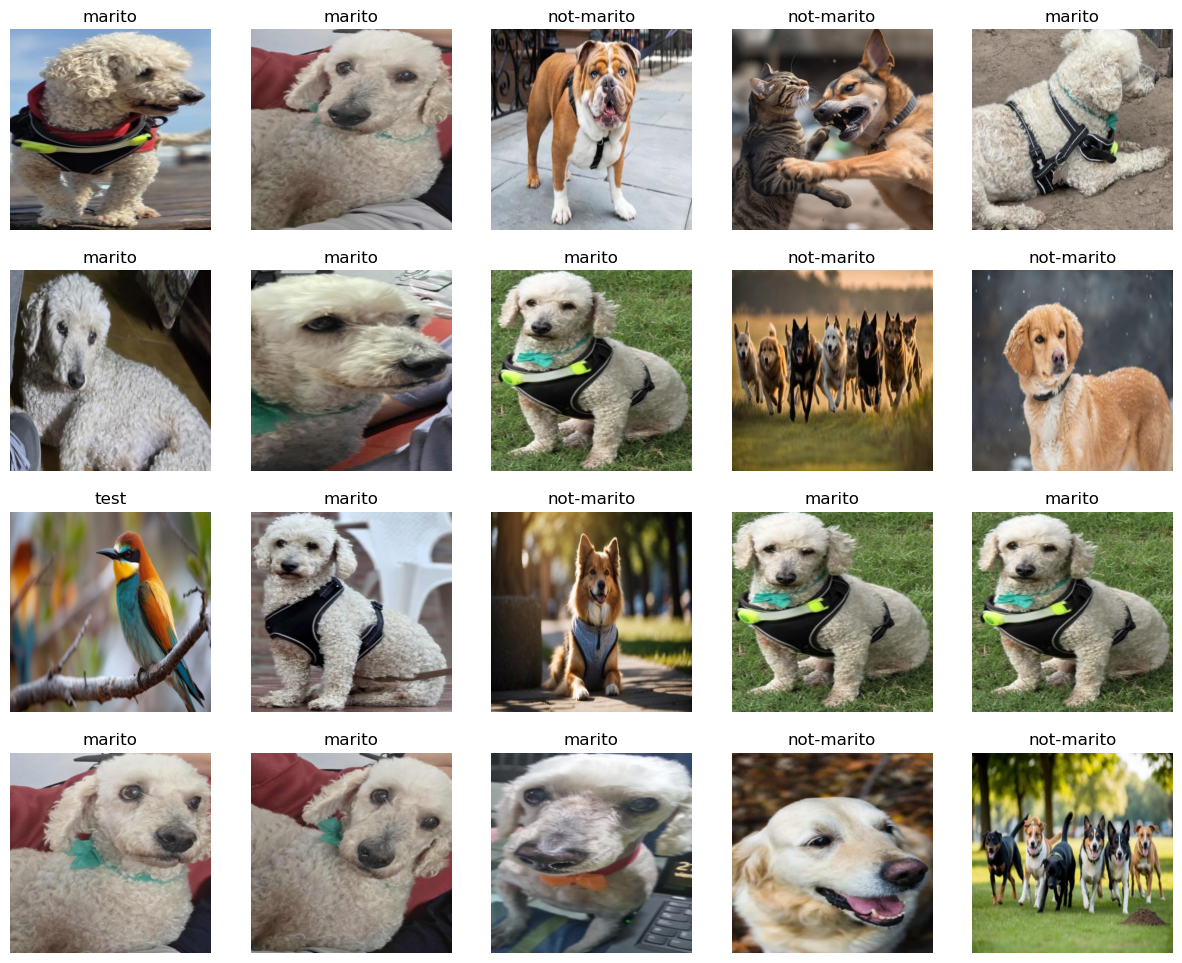

In [20]:
# Prepare data for model training

# Create a DataBlock for the bird vs dog classification task
# DataBlock -> a representation of your data for easy consumption of the model
dls = DataBlock(
  blocks=(ImageBlock, CategoryBlock), # What the model will take as input (image) and output (category, i.e., bird or dog)
  get_items=get_image_files, # The function to get the input (i.e. images from the path)
  splitter=RandomSplitter(valid_pct=0.2, seed=42), # Split the data into training and validation sets
  get_y=parent_label, # The function to get the labels (i.e. parent folder name)
  item_tfms=Resize(400, method=ResizeMethod.Squish) # Input transformations (i.e. resize the images to 400x400)
)

# Load data
# Create the dataloaders with a batch size of 32
# Dataloaders are used to load the data in batches for training and validation
# Batch size is the number of samples that will be propagated through the network at once
dls = dls.dataloaders(path, bs=32)

# See a batch of images and their labels
dls.show_batch(max_n=20)

In [21]:
# Create and train the model

# resnet18 is a convolutional neural network architecture that is 18 layers deep. It is a smaller version of the ResNet architecture, which is known for its ability to train very deep networks by using skip connections to allow gradients to flow through the network more easily.
# It is pretained on the ImageNet dataset, which contains millions of images and thousands of classes. This allows the model to learn general features that can be useful for a wide range of image classification tasks so that we dont have to train the model from scratch, which would require a large amount of data and computational resources.
# It uses concept of transfer learning, which is a technique where a model trained on one task is reused for a different but related task. In this case, we are using a model trained on ImageNet to classify images of birds and dogs.
# Under the hood, it replaces the final layer of the network with a new layer that has the same number of outputs as the number of classes in our dataset (i.e. 2 for bird and dog). The rest of the layers are frozen, meaning that their weights will not be updated during training. This allows us to leverage the knowledge learned by the model on ImageNet while still allowing it to learn features specific to our dataset.
learn = vision_learner(dls, resnet18, metrics=error_rate)

# Fine-tune the model for 3 epochs.
# Fine-tuning is a process where we train the model on our dataset for a few epochs to adjust the weights of the final layer to our specific task. This allows the model to learn features that are specific to our dataset while still leveraging the knowledge learned from ImageNet.
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,2.045403,3.538626,1.000000,00:53


epoch,train_loss,valid_loss,error_rate,time
0,1.608780,2.753534,1.000000,01:51
1,1.421332,2.255619,0.909091,02:07
2,1.094789,1.579252,0.727273,03:40


In [23]:
# Test the model
confidence_threshold = 0.8

pred = learn.predict(PILImage.create('data/test/marito.jpg'))
# Output the prediction and the confidence of the prediction
result,_,probs = pred
confidence = probs[0].item()

verdict = "marito" if result == "marito" and confidence > confidence_threshold else "not-marito"

print(f"This is a: {verdict}.")
print(f"Confidence: {confidence:.4f}")

This is a: not-marito.
Confidence: 0.0357
